In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
df = pd.read_csv("../data/processed/master_2024.csv", sep=",", encoding="UTF-8")

print(df.columns)

Index(['Name', 'Typ', 'ROR', 'erz. Hilfen absolut', 'erz. Hilfen pro 10000',
       '35a Hilfen absolut', '35a Hilfen pro 10000', 'Überörtlicher Träger',
       'Bevölkerung 6 bis 20', 'Anteil Kinder a.d. Gesamtbev.', 'SGB II-Quote',
       'Kinderarztdichte', 'KJP-Dichte'],
      dtype='object')


### Variablen

* Zielvariable (y_i): **§35a-Hilfen pro 10.000**
* Gruppenvariable (T_i \in {\text{LWL}, \text{LVR}})

### Nullhypothese (H₀)
*Die mittlere Inanspruchnahme von §35a-Hilfen pro 10.000 ist bei LWL und LVR gleich.*


---

### Primärer Test

**Welch-t-Test**
(für annährend normalverteilte Variablen, keine Varianzgleichheit)


### Robustheitscheck 

**Mann-Whitney-U** (nicht-parametrisch)

---

## 3) Effektgröße 

* **Cohen’s d** (für Welch-t)


Interpretation:

* d ≈ 0,2 → kleiner Effekt
* d ≈ 0,5 → mittlerer Effekt
* d ≥ 0,8 → großer Effekt

---
---

## 5) Ergebnislogik (

* **p ≥ 0,05**
  → *Die Nullhypothese kann nicht verworfen werden.*
  → Kein empirischer Hinweis auf einen Trägereffekt.

* **p < 0,05**
  → *Die Nullhypothese wird verworfen.*
  → Die Daten sprechen gegen die Annahme eines fehlenden Trägereffekts.


---


> *Prüfen, bb bei identischer gesetzlicher Grundlage und vergleichbarer Datenbasis Unterschiede auftreten, die allein mit der Trägerzuordnung korrespondieren.*


---



n LWL: 27  | n LVR: 25

Deskriptiv:
             LWL      LVR  diff (LVR-LWL)
mean    162.333  205.040          42.707
median  151.000  186.000          35.000
std      60.504   67.846           7.342
min      74.000   69.000          -5.000
max     306.000  326.000          20.000


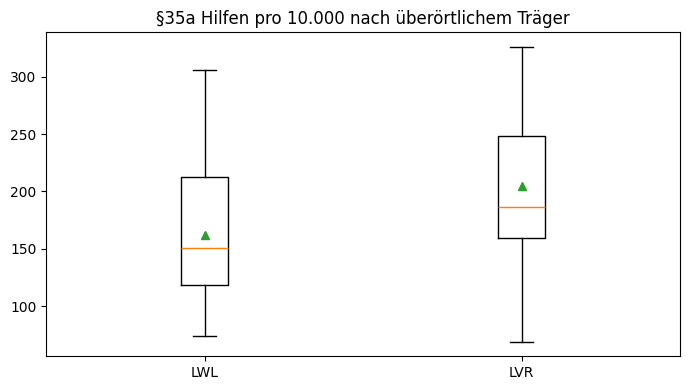

In [3]:
d = df[["Überörtlicher Träger", "35a Hilfen pro 10000"]].copy()

# Object-Spalten encoden
y_lwl = d.loc[d["Überörtlicher Träger"] == "LWL", "35a Hilfen pro 10000"].to_numpy()
y_lvr = d.loc[d["Überörtlicher Träger"] == "LVR", "35a Hilfen pro 10000"].to_numpy()

print("n LWL:", y_lwl.size, " | n LVR:", y_lvr.size)

# Beschreibung und grafische Darstellung
def desc(x):
    return pd.Series({
        "mean": np.mean(x),
        "median": np.median(x),
        "std": np.std(x, ddof=1) if x.size > 1 else np.nan,
        "min": np.min(x),
        "max": np.max(x),
    })



desc_table = pd.DataFrame({
    "LWL": desc(y_lwl),
    "LVR": desc(y_lvr),
})

desc_table["diff (LVR-LWL)"] = desc_table["LVR"] - desc_table["LWL"]

print("\nDeskriptiv:\n", desc_table.round(3))

plt.figure(figsize=(7, 4))
plt.boxplot([y_lwl, y_lvr], tick_labels=["LWL", "LVR"], showmeans=True)
plt.title("§35a Hilfen pro 10.000 nach überörtlichem Träger")
plt.tight_layout()
plt.show()

In [5]:
# Welch-t-Test 
t_stat, p_val = stats.ttest_ind(y_lvr, y_lwl, equal_var=False)  


mean_diff = np.mean(y_lvr) - np.mean(y_lwl)
s1 = np.var(y_lvr)
s2 = np.var(y_lwl)
n1, n2 = y_lvr.size, y_lwl.size
se = np.sqrt(s1/n1 + s2/n2)

# Effektgröße: Cohen's d 
sp = np.sqrt(((n1-1)*s1 + (n2-1)*s2) / (n1 + n2 - 2))
cohen_d = mean_diff / sp



print("\nWelch-t-Test (H0: Mittelwerte gleich)")
print(f"t = {t_stat:.3f}, p = {p_val:.4f}")
print(f"Mittelwertsdifferenz (LVR - LWL) = {mean_diff:.3f}")


print("\nEffektgröße:")
print(f"Cohen's d (LVR - LWL) = {cohen_d:.3f}")


Welch-t-Test (H0: Mittelwerte gleich)
t = 2.388, p = 0.0209
Mittelwertsdifferenz (LVR - LWL) = 42.707

Effektgröße:
Cohen's d (LVR - LWL) = 0.679


In [6]:
#  Mann-Whitney-U 
u_stat, p_u = stats.mannwhitneyu(y_lvr, y_lwl, alternative="two-sided")
print("\nRobustheitscheck (Mann-Whitney-U):")
print(f"U = {u_stat:.1f}, p = {p_u:.4f}")


Robustheitscheck (Mann-Whitney-U):
U = 470.0, p = 0.0156


In [8]:
print(
    f"Ein Welch-t-Test ergab für den Unterschied der §35a-Hilfen pro 10.000 "
    f"zwischen LVR und LWL einen Mittelwertsunterschied von {mean_diff:.3f} "
    f"(t-stat = {t_stat:.3f}, p = {p_val:.4f}.) "
    f"Die Nullhypothese wurde bei α = 0,05 verworfen. "
    f"Die Effektgröße betrug Cohen's d = {cohen_d:.3f}."
)

Ein Welch-t-Test ergab für den Unterschied der §35a-Hilfen pro 10.000 zwischen LVR und LWL einen Mittelwertsunterschied von 42.707 (t-stat = 2.388, p = 0.0209.) Die Nullhypothese wurde bei α = 0,05 verworfen. Die Effektgröße betrug Cohen's d = 0.679.
